# RAMIP path-independence at GWL 2.0 — beyond `tas`

Same test as `ks_path_independence_ramip_gwl.ipynb` (pixel-wise block-permutation KS, samples
matched at the first 10-yr window reaching **2.0 K** per run per experiment), applied to
**`pr`, `tasmax`, `tasmin`**. The GWL windows are defined by GMST (`tas`), cached in
`gwl2.0_windows.csv`, and reused unchanged — the question is whether *other* variables stay
path-independent once global-mean warming is matched.

Reference land fractions from the `tas` run: rejections 0.034–0.086 vs floor 0.057.

In [1]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats as sstats
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import regionmask

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/path_independence')
from funcs_support import get_params
import ks_tools as kt
dir_list = get_params()

warnings.filterwarnings('ignore', category=FutureWarning)

RAW    = dir_list['raw'] + 'ramip/'
OTHER  = 'ssp370-126aer'
ANCHOR = {m: 'ssp370' for m in
          ['CanESM5-1', 'CNRM-ESM2-1', 'EC-Earth3-AerChem', 'GISS-E2-1-G', 'MIROC6',
           'MRI-ESM2-0', 'NorESM2-LM', 'UKESM1-0-LL']}
ANCHOR['CESM2'] = 'ssp370-LE'
MODELS = sorted(ANCHOR)

VARS   = ['pr', 'tasmax', 'tasmin']
GWL    = 2.0
WIN    = 10
ALPHA  = 0.05
NDRAWS = 999
BLOCK  = 12

GWL_DIR = dir_list['aux'] + 'diagnostics/ramip_gwl/'
out_dir = dir_list['aux'] + '../figures/'

# GWL windows computed (from tas GMST) in ks_path_independence_ramip_gwl.ipynb
win_df = pd.read_csv(f'{GWL_DIR}gwl{GWL}_windows.csv')
USABLE = {m: win_df[(win_df.model == m) & win_df.usable] for m in MODELS}
GWL_MODELS = [m for m in MODELS if len(USABLE[m])]
print('models:', GWL_MODELS)


def member_files(mod, exp, var):
    """run -> file. Some runs exist at several time spans; keep the longest."""
    out = {}
    for f in sorted(glob.glob(f'{RAW}{mod}/{var}_Amon_{mod}_{exp}_r*.zarr')):
        run = re.search(r'_(r\d+i\d+p\d+f\d+)_', f).group(1)
        end = re.search(r'-(\d{4})\d{4}\.zarr$', f)
        end = int(end.group(1)) if end else 0
        if run not in out or end > out[run][1]:
            out[run] = (f, end)
    return {r: v[0] for r, v in out.items()}

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


models: ['CESM2', 'CNRM-ESM2-1', 'CanESM5-1', 'EC-Earth3-AerChem', 'GISS-E2-1-G', 'MIROC6', 'MRI-ESM2-0', 'UKESM1-0-LL']


## KS

Verbatim from `ks_path_independence_ramip_gwl.ipynb` (numba `ks_statistic_sorted` from the `4-fig_impact_figures.ipynb`; block-permutation size verified in
`ks_block_permutation.ipynb`). `window_vals` gains a `var` argument.

In [2]:
from numba import njit, prange, set_num_threads
set_num_threads(16)


@njit
def ks_statistic_sorted(x, y):
    """KS statistic for already-sorted arrays (verbatim from 4-fig_impact_figures.ipynb)."""
    nx = len(x); ny = len(y)
    i = 0; j = 0
    cdfx = 0.0; cdfy = 0.0
    d = 0.0
    while i < nx and j < ny:
        if x[i] <= y[j]:
            i += 1
            cdfx = i / nx
        else:
            j += 1
            cdfy = j / ny
        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff
    while i < nx:
        i += 1
        cdfx = i / nx
        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff
    while j < ny:
        j += 1
        cdfy = j / ny
        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff
    return d


@njit
def ks_block_permutation_test(x, y, block=12, ndraws=999):
    """Block-permutation KS p (size verified in ks_block_permutation.ipynb)."""
    nx = len(x); ny = len(y)
    nbx = nx // block; nby = ny // block
    nb = nbx + nby
    D_obs = ks_statistic_sorted(np.sort(x.copy()), np.sort(y.copy()))
    pool = np.empty(nx + ny, dtype=x.dtype)
    pool[:nx] = x
    pool[nx:] = y
    order = np.arange(nb)
    xperm = np.empty(nx, dtype=x.dtype)
    yperm = np.empty(ny, dtype=x.dtype)
    exceed = 0
    for draw in range(ndraws):
        for i in range(nb - 1, 0, -1):
            j = np.random.randint(i + 1)
            tmp = order[i]; order[i] = order[j]; order[j] = tmp
        for b in range(nbx):
            s = order[b] * block
            xperm[b * block:(b + 1) * block] = pool[s:s + block]
        for b in range(nby):
            s = order[nbx + b] * block
            yperm[b * block:(b + 1) * block] = pool[s:s + block]
        xperm.sort(); yperm.sort()
        if ks_statistic_sorted(xperm, yperm) >= D_obs:
            exceed += 1
    return (exceed + 1) / (ndraws + 1)   # Phipson & Smyth 2010


@njit(parallel=True)
def block_perm_map(A, B, block=12, ndraws=999):
    """p-value per pixel; A, B are (pixels, time)."""
    P = A.shape[0]
    out = np.empty(P)
    for px in prange(P):
        out[px] = ks_block_permutation_test(A[px], B[px], block, ndraws)
    return out


def ks_fast(a1, a2):
    """asymptotic p per pixel"""
    P, n1 = a1.shape; n2 = a2.shape[1]
    z = np.concatenate([a1, a2], axis=1)
    order = np.argsort(z, axis=1, kind='stable')
    zs = np.take_along_axis(z, order, axis=1)
    ind = np.where(order < n1, 1.0 / n1, -1.0 / n2)
    cd = np.cumsum(ind, axis=1)
    valid = np.ones_like(cd, dtype=bool)
    valid[:, :-1] = zs[:, 1:] != zs[:, :-1]
    D = np.abs(np.where(valid, cd, 0.0)).max(axis=1)
    en = int(np.round(n1 * n2 / (n1 + n2)))
    uD, inv = np.unique(D, return_inverse=True)
    return np.clip(sstats.kstwo.sf(uD, en), 0, 1)[inv]


def window_vals(fn, var, y_end, win=WIN):
    """monthly values over the `win` years ending at y_end, as (pixels, months)."""
    ds = xr.open_zarr(fn, consolidated=False)
    yr = ds.time.dt.year
    da = ds[var].sel(time=(yr > y_end - win) & (yr <= y_end))
    v = da.load().transpose('lat', 'lon', 'time')
    return v.values.reshape(-1, v.sizes['time']), v.lat, v.lon, v.sizes['time']


_r = np.random.default_rng(0)
_x, _y = _r.standard_normal((2, 120)), _r.standard_normal((2, 120))
print('iid check  perm:', np.round(block_perm_map(_x, _y, BLOCK, NDRAWS), 3),
      ' asymptotic:', np.round(ks_fast(_x, _y), 3))

iid check  perm: [0.338 0.784]  asymptotic: [0.451 0.66 ]


## KS maps per variable

Same windows as the `tas` analysis (per run, per experiment). Runs missing a variable's file
are skipped and reported. Cache: `ramip_gwl/ks_{var}/{model}.nc`.

In [3]:
results = {}
for var in VARS:
    ks_dir = f'{GWL_DIR}ks_{var}/'
    os.makedirs(ks_dir, exist_ok=True)
    for mod in GWL_MODELS:
        cache_fn = f'{ks_dir}{mod}.nc'
        if os.path.exists(cache_fn):
            results[(var, mod)] = xr.open_dataset(cache_fn).load()
            print(f'{var} {mod}: loaded cache ({results[(var, mod)].sizes["run"]} runs)')
            continue
        afns = member_files(mod, ANCHOR[mod], var)
        bfns = member_files(mod, OTHER, var)
        bp, asy, runs_used = [], [], []
        for _, row in USABLE[mod].iterrows():
            if row.run not in afns or row.run not in bfns:
                print(f'  {var} {mod} {row.run}: no {var} file, skipped')
                continue
            va, lat, lon, n1 = window_vals(afns[row.run], var, int(row.anchor_end))
            vb, *_, n2       = window_vals(bfns[row.run], var, int(row.other_end))
            if n1 != 12 * WIN or n2 != 12 * WIN:
                print(f'  {var} {mod} {row.run}: short window {n1}/{n2} months, skipped')
                continue
            bp.append(block_perm_map(va, vb, BLOCK, NDRAWS).reshape(len(lat), len(lon)))
            asy.append(ks_fast(va, vb).reshape(len(lat), len(lon)))
            runs_used.append(row.run)
            print(f'  {var} {mod} {row.run} done', flush=True)
        if not runs_used:
            print(f'{var} {mod}: nothing usable')
            continue
        dims = ('run', 'lat', 'lon')
        ds = xr.Dataset({'p_blockperm': (dims, np.stack(bp)),
                         'p_asymptotic': (dims, np.stack(asy))},
                        coords={'run': runs_used, 'lat': lat, 'lon': lon})
        ds.attrs['gwl'] = GWL
        ds.attrs['variable'] = var
        ds.to_netcdf(cache_fn)
        results[(var, mod)] = ds
        print(f'{var} {mod}: {len(runs_used)} runs -> {cache_fn}')

pr CESM2: loaded cache (10 runs)
pr CNRM-ESM2-1: loaded cache (6 runs)
pr CanESM5-1: loaded cache (10 runs)
pr EC-Earth3-AerChem: loaded cache (6 runs)


pr GISS-E2-1-G: loaded cache (10 runs)
pr MIROC6: loaded cache (10 runs)


pr MRI-ESM2-0: loaded cache (10 runs)
pr UKESM1-0-LL: loaded cache (10 runs)
tasmax CESM2: loaded cache (10 runs)
tasmax CNRM-ESM2-1: loaded cache (6 runs)


tasmax CanESM5-1: loaded cache (10 runs)
tasmax EC-Earth3-AerChem: loaded cache (6 runs)
tasmax GISS-E2-1-G: loaded cache (10 runs)


tasmax MIROC6: loaded cache (10 runs)
tasmax MRI-ESM2-0: loaded cache (10 runs)


tasmax UKESM1-0-LL: loaded cache (10 runs)
tasmin CESM2: loaded cache (9 runs)


tasmin CNRM-ESM2-1: loaded cache (6 runs)
tasmin CanESM5-1: loaded cache (10 runs)
tasmin EC-Earth3-AerChem: loaded cache (6 runs)
tasmin GISS-E2-1-G: loaded cache (10 runs)
tasmin MIROC6: loaded cache (10 runs)


tasmin MRI-ESM2-0: loaded cache (10 runs)
tasmin UKESM1-0-LL: loaded cache (10 runs)


## Land fractions vs `tas`

Per-run-mean land fraction with block-perm p < 0.05, per variable, with the `tas` GWL-matched
result (from `ramip_gwl/ks/`) alongside. Anything near **0.057** (the test's measured
false-positive rate on same-forcing pairs) is indistinguishable from path-independence.

In [4]:
tas_cache = {m: xr.open_dataset(f'{GWL_DIR}ks/{m}.nc').load() for m in GWL_MODELS
             if os.path.exists(f'{GWL_DIR}ks/{m}.nc')}

rows = []
for mod in GWL_MODELS:
    row = {'model': mod,
           'tas': kt.land_fraction(tas_cache[mod], 'run', ALPHA) if mod in tas_cache else np.nan}
    for var in VARS:
        row[var] = (kt.land_fraction(results[(var, mod)], 'run', ALPHA)
                    if (var, mod) in results else np.nan)
    rows.append(row)
frac_df = pd.DataFrame(rows).set_index('model').sort_values('pr', ascending=False)
frac_df.to_csv(f'{GWL_DIR}land_fractions_vars.csv')
print(frac_df.round(3))
print('\nfalse-positive floor (same-forcing ensemble pairs): 0.057')

                     tas     pr  tasmax  tasmin
model                                          
EC-Earth3-AerChem  0.071  0.062   0.069   0.053
MRI-ESM2-0         0.054  0.056   0.059   0.051
MIROC6             0.066  0.050   0.075   0.052
CanESM5-1          0.040  0.049   0.044   0.036
GISS-E2-1-G        0.045  0.048   0.046   0.044
CESM2              0.069  0.045   0.047   0.067
CNRM-ESM2-1        0.049  0.044   0.050   0.049
UKESM1-0-LL        0.066  0.044   0.061   0.060

false-positive floor (same-forcing ensemble pairs): 0.057


## Figures

Left: land-fraction summary across variables (dashed line = 0.057 floor).
Then per-variable q01 maps (original cmap convention: cmocean `amp_r`, bottom 5% purple).
Caveat carried over from the `tas` notebook: at N=6–10 runs q01 ≈ min and reads darker than the
statistics warrant — the land-fraction table is the quantitative result, the maps show *where*.

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_blockperm_landfrac_vars_gwl2.0.png


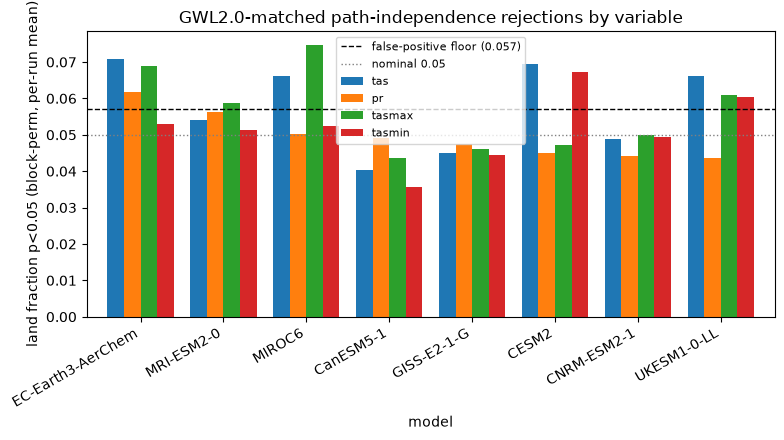

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
frac_df[['tas'] + VARS].plot.bar(ax=ax, width=0.8)
ax.axhline(0.057, color='k', ls='--', lw=1, label='false-positive floor (0.057)')
ax.axhline(ALPHA, color='grey', ls=':', lw=1, label=f'nominal {ALPHA}')
ax.set_ylabel(f'land fraction p<{ALPHA} (block-perm, per-run mean)')
ax.set_title(f'GWL{GWL}-matched path-independence rejections by variable')
ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
fig.tight_layout()
fig.savefig(out_dir + f'ks_blockperm_landfrac_vars_gwl{GWL}.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + f'ks_blockperm_landfrac_vars_gwl{GWL}.png')

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_blockperm_maps_ramip_gwl2.0_pr.png


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_blockperm_maps_ramip_gwl2.0_tasmax.png


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_blockperm_maps_ramip_gwl2.0_tasmin.png


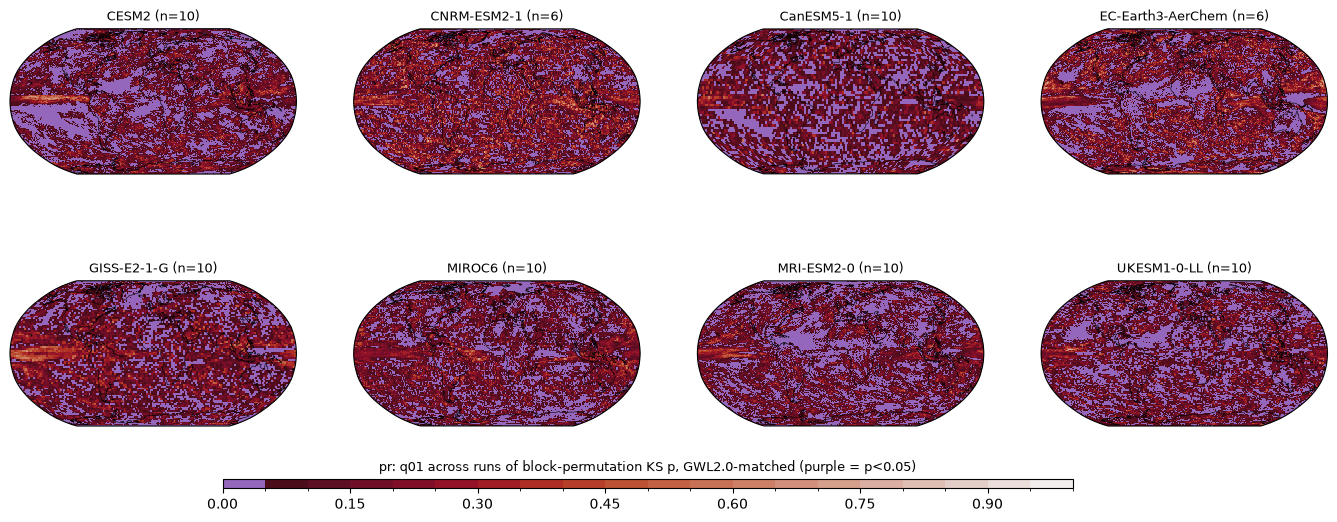

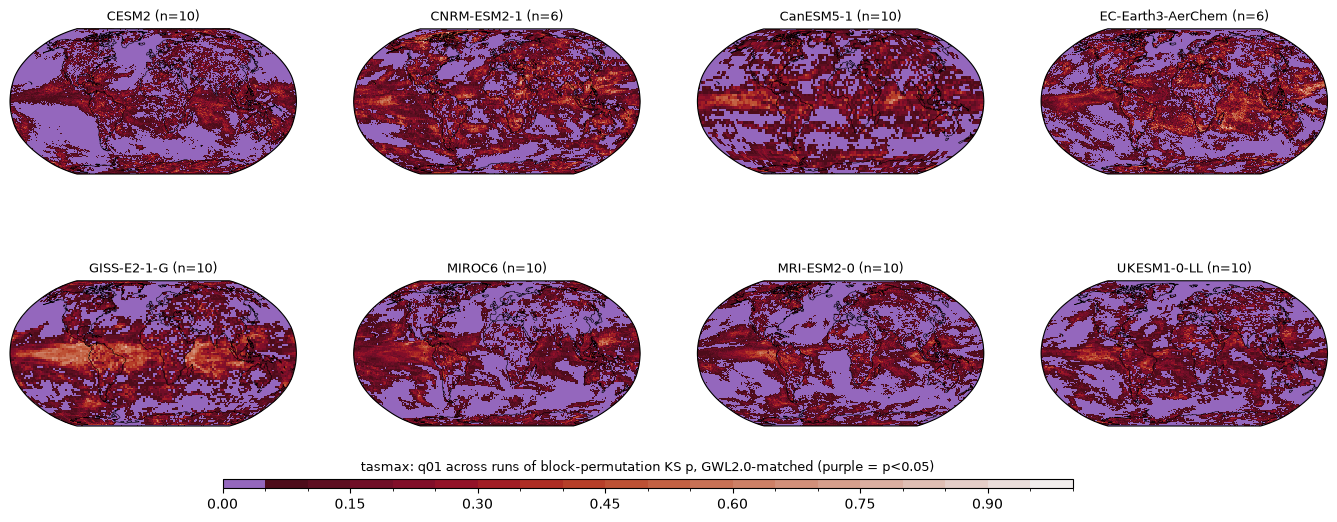

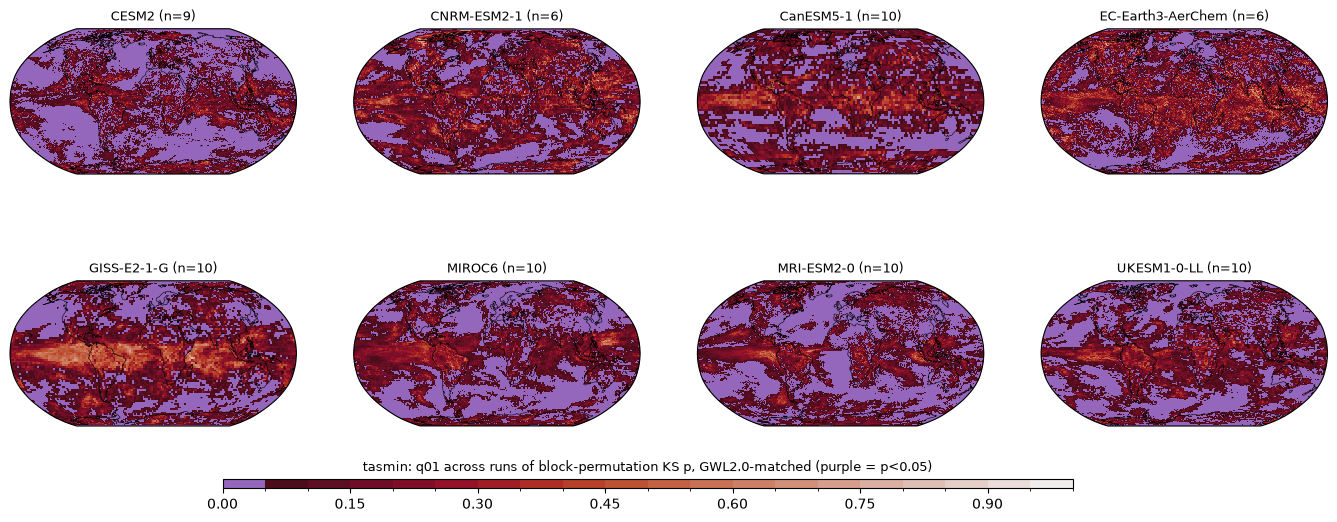

In [6]:
base = cmocean.cm.amp_r(np.linspace(0, 1, 20))
base[0] = mpl.colors.to_rgba('tab:purple')
cmap = mpl.colors.ListedColormap(base)
norm = mpl.colors.BoundaryNorm(np.linspace(0, 1, 21), 20)

for var in VARS:
    mods = [m for m in GWL_MODELS if (var, m) in results]
    fig, axs = plt.subplots(2, 4, figsize=(17, 6),
                            subplot_kw={'projection': ccrs.Robinson()})
    for ax in axs.flat[len(mods):]:
        ax.set_visible(False)
    for ax, mod in zip(axs.flat, mods):
        q01 = results[(var, mod)].p_blockperm.quantile(0.01, dim='run')
        im = ax.pcolormesh(q01.lon, q01.lat, q01, cmap=cmap, norm=norm,
                           transform=ccrs.PlateCarree())
        ax.coastlines(lw=0.4)
        ax.set_title(f'{mod} (n={results[(var, mod)].sizes["run"]})', fontsize=9)
    cax = fig.add_axes([0.25, 0.06, 0.5, 0.015])
    fig.colorbar(im, cax=cax, orientation='horizontal')
    cax.set_title(f'{var}: q01 across runs of block-permutation KS p, GWL{GWL}-matched '
                  f'(purple = p<0.05)', fontsize=9)
    fig.savefig(out_dir + f'ks_blockperm_maps_ramip_gwl{GWL}_{var}.png',
                dpi=150, bbox_inches='tight')
    print('saved', out_dir + f'ks_blockperm_maps_ramip_gwl{GWL}_{var}.png')